In [1]:
import sys
sys.path.append('../')
from utils_models import *

# Initialize a integer fluxonium - readout resonator system, and find the dressed indices of the hybridized states

In [2]:
qbt = scqubits.Fluxonium(EJ = 2.65,
                        EC = 0.6,
                        EL = 0.13,
                        truncated_dim=10,
                        cutoff = 110,
                        flux = 0)
evals = qbt.eigenvals()
evals[3]-evals[0]

2.9608889176904216

# drive qubit, purcell decay

In [55]:
Er = 2.97
g =  0.2 
kappa = 4e-2 # kappa = Er * 2pi/Q =0.1

Gamma = kappa*g**2/(evals[3]-evals[0] - Er)**2
print(f"purcell decay rate {Gamma}")

max_ql = 8
max_ol = 3
system = FluxoniumOscillatorSystem(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    kappa = kappa, 
    products_to_keep=[[ql, ol] for ql in range(8) for ol in range(4) ],
    computaional_states = '0,1',
    )

evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)
def print_top_two_dressed_state(product_index):
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]
    sorted_overlaps = overlaps_with_product_state[sorted_indices]
    print(list(sorted_indices)[:2])
    print(list(sorted_overlaps)[:2])
# Find what dressed states make up the g1 (01) product state
print_top_two_dressed_state(0 * system.osc.truncated_dim + 1)
# Find what dressed states make up the h0 (30) product state
print_top_two_dressed_state( 3 * system.osc.truncated_dim + 0)
# Find what dressed states make up the (40) product state
print_top_two_dressed_state(4 * system.osc.truncated_dim + 0)

qbt_operator_element = np.abs(system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator))[2,3]) 
print(qbt_operator_element)
oscillator_operator_element = np.abs(system.truncate_function(
    system.hilbertspace.op_in_dressed_eigenbasis(system.osc.annihilation_operator)
    + system.hilbertspace.op_in_dressed_eigenbasis(system.osc.creation_operator)
    )[2,3]) 
print(oscillator_operator_element)


qbt_operator_element24 = np.abs(system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator))[2,4]) 
print(qbt_operator_element24)
oscillator_operator_element24 = np.abs(system.truncate_function(
    system.hilbertspace.op_in_dressed_eigenbasis(system.osc.annihilation_operator)
    + system.hilbertspace.op_in_dressed_eigenbasis(system.osc.creation_operator)
    )[2,4]) 
print(oscillator_operator_element24)


amp = 0.03
square_t_stop = 0.5 / qbt_operator_element /amp
print(f"square_t_stop:{square_t_stop}")
t_rise = 30
area_under_square  = square_t_stop
area_under_rise_and_fall = t_rise
t_stop = 2 * t_rise + (area_under_square-area_under_rise_and_fall)
tot_time = int(t_stop + 500)
tlist = np.linspace(0, tot_time, tot_time)
kappa = 3e-2

results = system.run_mesolve_parrallel(
    initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
    tlist = tlist,
    drive_terms = [
        DriveTerm(
            driven_op =system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator)),
            pulse_shape_func = square_pulse_with_rise_fall,
            pulse_shape_args={
                'w_d': system.hilbertspace.energy_by_bare_index((2,1))-system.hilbertspace.energy_by_bare_index((2,0)),
                'amp':amp,
                't_rise':t_rise,
                't_square': t_stop-2*t_rise,
            }
        )
    ],
    c_ops=system.c_ops,
    e_ops=[# we want to get the expectation value of the system being in every one of its eigenstates
        system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension,i))) for i in [0,1,2,3,4,5,6,7]
    ],
)


square_t_stop:140.45481108774575


 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/multiprocessing/popen_fork.py: 66

 *********76%*****      ] Elapsed 49.12s / Remaining 00:00:00:1500[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00 [          0%           ] Elapsed 0.03s / Remaining 00:00:00:00 [          0%           ] Elapsed 0.03s / Remaining 00:00:00:00[          0%           ] Elapsed 0.04s / Remaining 00:00:00:00 [          0%           ] Elapsed 0.08s / Remaining 00:00:00:00[          0%           ] Elapsed 0.09s / Remaining 00:00:00:00[          0%           ] Elapsed 0.13s / Remaining 00:00:00:00[          0%           ] Elapsed 0.13s / Remaining 00:00:00:00[          0%           ] Elapsed 0.15s / Remaining 00:00:00:00[          1%           ] Elapsed 0.19s / Remaining 00:00:00:18  [          1%           ] Elapsed 0.20s / Remaining 00:00:00:19[          1%           ] Elapsed 0.20s / Remaining 00:00:00:20[          1%           ] Elapsed 0.23s / Remaining 00:00:00:23[          1%           ] Elapsed 0.28s / Remai

Processing states with pad_back_custom:   0%|          | 0/670 [00:00<?, ?it/s]

 [*********76%*****      ] Elapsed 49.29s / Remaining 00:00:00:15[*********83%*******    ] Elapsed 49.30s / Remaining 00:00:00:10[*********76%*****      ] Elapsed 49.35s / Remaining 00:00:00:15[*********83%*******    ] Elapsed 49.37s / Remaining 00:00:00:10

...

Processing states with pad_back_custom:  80%|████████  | 537/670 [00:00<00:00, 5365.81it/s]

 [*********93%*********  ] Elapsed 55.28s / Remaining 00:00:00:04

Processing states with pad_back_custom: 100%|██████████| 670/670 [00:00<00:00, 5369.20it/s]


 [*********93%*********  ] Elapsed 55.34s / Remaining 00:00:00:04[*********93%*********  ] Elapsed 55.44s / Remaining 00:00:00:04[*********93%*********  ] Elapsed 55.53s / Remaining 00:00:00:04[*********93%*********  ] Elapsed 55.59s / Remaining 00:00:00:04[*********94%********** ] Elapsed 55.65s / Remaining 00:00:00:03[*********94%********** ] Elapsed 55.69s / Remaining 00:00:00:03[*********94%********** ] Elapsed 55.75s / Remaining 00:00:00:03[*********94%********** ] Elapsed 55.80s / Remaining 00:00:00:03[*********94%********** ] Elapsed 55.88s / Remaining 00:00:00:03[*********94%********** ] Elapsed 55.97s / Remaining 00:00:00:03[*********94%********** ] Elapsed 56.05s / Remaining 00:00:00:03[*********95%********** ] Elapsed 56.13s / Remaining 00:00:00:02[*********95%********** ] Elapsed 56.21s / Remaining 00:00:00:02[*********95%********** ] Elapsed 56.30s / Remaining 00:00:00:02[*********95%********** ] Elapsed 56.39s / Remaining 00:00:00:02[*********95%********** ] Elapsed 56.48

Processing states with pad_back_custom: 100%|██████████| 670/670 [00:00<00:00, 4668.14it/s]


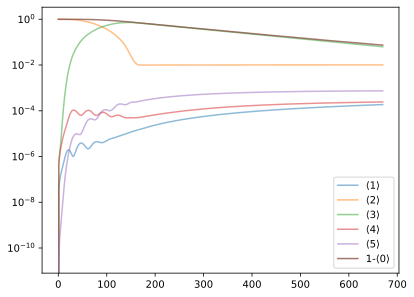

In [48]:
## For system starting in dressed state 2 
# (which is f0, the leakage state we are addressing) 
# about 99.99% of the population has gone to state 0 (which is g0) at 700 ns
for i in [1,2,3, 4,5]:
    plt.plot(tlist,results[2].expect[i],label=fr'$\langle{i}\rangle$',alpha = 0.5)
plt.plot(tlist,1-results[2].expect[0],label=fr'1-$\langle{0}\rangle$',alpha = 0.8)
plt.legend()
plt.yscale('log')


# drive oscillator, oscillator decay

In [61]:
Er = 2.97
g =  0.2 
kappa = 4e-2 # kappa = Er * 2pi/Q =0.1

Gamma = kappa*g**2/(evals[3]-evals[0] - Er)**2
print(f"purcell decay rate {Gamma}")

max_ql = 8
max_ol = 3
system = FluxoniumOscillatorSystem(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    kappa = kappa, 
    products_to_keep=[[ql, ol] for ql in range(8) for ol in range(4) ],
    computaional_states = '0,1',
    )

evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)
def print_top_two_dressed_state(product_index):
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]
    sorted_overlaps = overlaps_with_product_state[sorted_indices]
    print(list(sorted_indices)[:2])
    print(list(sorted_overlaps)[:2])
# Find what dressed states make up the g1 (01) product state
print_top_two_dressed_state(0 * system.osc.truncated_dim + 1)
# Find what dressed states make up the h0 (30) product state
print_top_two_dressed_state( 3 * system.osc.truncated_dim + 0)
# Find what dressed states make up the (40) product state
print_top_two_dressed_state(4 * system.osc.truncated_dim + 0)

qbt_operator_element = np.abs(system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator))[2,3]) 
print(qbt_operator_element)
oscillator_operator_element = np.abs(system.truncate_function(
    system.hilbertspace.op_in_dressed_eigenbasis(system.osc.annihilation_operator)
    + system.hilbertspace.op_in_dressed_eigenbasis(system.osc.creation_operator)
    )[2,3]) 
print(oscillator_operator_element)


qbt_operator_element24 = np.abs(system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator))[2,4]) 
print(qbt_operator_element24)
oscillator_operator_element24 = np.abs(system.truncate_function(
    system.hilbertspace.op_in_dressed_eigenbasis(system.osc.annihilation_operator)
    + system.hilbertspace.op_in_dressed_eigenbasis(system.osc.creation_operator)
    )[2,4]) 
print(oscillator_operator_element24)


amp = 0.03
square_t_stop = 0.5 / oscillator_operator_element /amp
print(f"square_t_stop:{square_t_stop}")
t_rise = 30
area_under_square  = square_t_stop
area_under_rise_and_fall = t_rise
t_stop = 2 * t_rise + (area_under_square-area_under_rise_and_fall)
tot_time = int(t_stop + 500)
tlist = np.linspace(0, tot_time, tot_time)
kappa = 3e-2

results = system.run_mesolve_parrallel(
    initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
    tlist = tlist,
    drive_terms = [
        DriveTerm(
            driven_op =system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator)),
            pulse_shape_func = square_pulse_with_rise_fall,
            pulse_shape_args={
                'w_d': system.hilbertspace.energy_by_bare_index((2,1))-system.hilbertspace.energy_by_bare_index((2,0)),
                'amp':amp,
                't_rise':t_rise,
                't_square': t_stop-2*t_rise,
            }
        )
    ],
    c_ops=system.c_ops,
    e_ops=[# we want to get the expectation value of the system being in every one of its eigenstates
        system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension,i))) for i in [0,1,2,3,4,5,6,7]
    ],
)


purcell decay rate 0.12844579360042335
[4, 3]
[0.7226556266433511, 0.6891659858851746]
[3, 4]
[0.7231000107008679, 0.6900370427964548]
[5, 9]
[0.9920361753947612, 0.07956075013753194]
0.11866212725354469
0.016415058339651355
0.11442377522878691
0.016302901788472053
square_t_stop:1015.3278972154209


 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/multiprocessing/popen_fork.py: 66

 ********100%***********] Elapsed 127.66s / Remaining 00:00:00:000[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.05s / Remaining 00:00:00:00[          0%           ] Elapsed 0.06s / Remaining 00:00:00:00[          0%           ] Elapsed 0.08s / Remaining 00:00:00:00[          0%           ] Elapsed 0.09s / Remaining 00:00:00:00[          0%           ] Elapsed 0.13s / Remaining 00:00:00:00[          0%           ] Elapsed 0.14s / Remaining 00:00:00:00[          0%           ] Elapsed 0.15s / Remaining 00:00:00:00[          0%           ] Elapsed 0.18s / Remaining 00:00:00:00[          0%           ] Elapsed 0.19s / Remaining 00:00:00:00[          0%           ] Elapsed 0.22s / Remaining 00:00:00:00[          0%           ] Elapsed 0.25s / Remaining 00:00:00:00[          0%           ] Elapsed 0.27s / Remaining 00:00:00:00[          0%           ] Elapsed 0.32s / Remaining 

Processing states with pad_back_custom:   0%|          | 0/1545 [00:00<?, ?it/s]

 [*********81%*******    ] Elapsed 127.75s / Remaining 00:00:00:29[*********93%*********  ] Elapsed 127.75s / Remaining 00:00:00:09[*********81%*******    ] Elapsed 127.82s / Remaining 00:00:00:29[*********93%*********  ] Elapsed 127.83s / Remaining 00:00:00:09

...

Processing states with pad_back_custom:  73%|███████▎  | 1121/1545 [00:00<00:00, 2832.32it/s]

 [*********88%********   ] Elapsed 135.54s / Remaining 00:00:00:18

Processing states with pad_back_custom: 100%|██████████| 1545/1545 [00:00<00:00, 3371.82it/s]


 *********88%********   ] Elapsed 135.90s / Remaining 00:00:00:188[*********88%********   ] Elapsed 135.68s / Remaining 00:00:00:18[*********88%********   ] Elapsed 135.76s / Remaining 00:00:00:18[*********88%********   ] Elapsed 135.83s / Remaining 00:00:00:18 [*********88%********   ] Elapsed 135.97s / Remaining 00:00:00:18[*********88%********   ] Elapsed 136.03s / Remaining 00:00:00:18[*********89%********   ] Elapsed 136.09s / Remaining 00:00:00:16[*********89%********   ] Elapsed 136.15s / Remaining 00:00:00:16[*********89%********   ] Elapsed 136.21s / Remaining 00:00:00:16[*********89%********   ] Elapsed 136.27s / Remaining 00:00:00:16[*********89%********   ] Elapsed 136.33s / Remaining 00:00:00:16[*********89%********   ] Elapsed 136.40s / Remaining 00:00:00:16[*********89%********   ] Elapsed 136.46s / Remaining 00:00:00:16[*********89%********   ] Elapsed 136.51s / Remaining 00:00:00:16[*********89%********   ] Elapsed 136.58s / Remaining 00:00:00:16[*********89%********  

Processing states with pad_back_custom: 100%|██████████| 1545/1545 [00:00<00:00, 3824.27it/s]


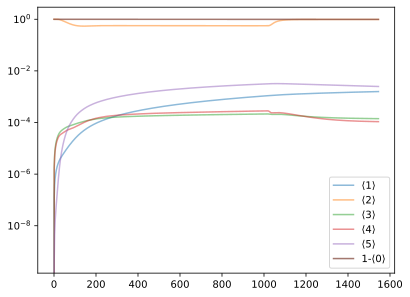

In [62]:
## For system starting in dressed state 2 
# (which is f0, the leakage state we are addressing) 
# about 99.99% of the population has gone to state 0 (which is g0) at 700 ns
for i in [1,2,3, 4,5]:
    plt.plot(tlist,results[2].expect[i],label=fr'$\langle{i}\rangle$',alpha = 0.5)
plt.plot(tlist,1-results[2].expect[0],label=fr'1-$\langle{0}\rangle$',alpha = 0.8)
plt.legend()
plt.yscale('log')


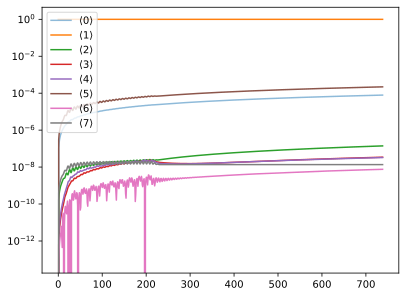

In [46]:
## For system starting in dressed state 1 (which is e0, a computational state) the worried qubit 1-4 transition only happens at a level of 1e-4

plt.plot(tlist,results[1].expect[0],label=fr'$\langle{0}\rangle$',alpha = 0.5)

for i in [1,2,3,4,5,6,7]:
    plt.plot(tlist,results[1].expect[i],label=fr'$\langle{i}\rangle$')
plt.legend()
# plt.ylim(0,1e-3)

plt.yscale('log')
# plt.xlim(0,186)

## For system starting in dressed state 0 (which is g0, a computational state) there's also some leakage on the level of 1e-5

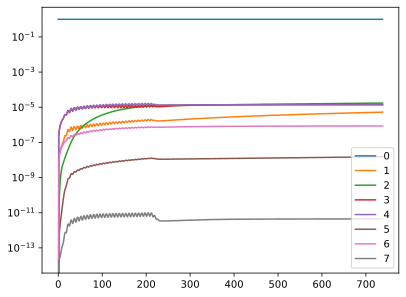

In [48]:
for i in [0,1,2,3,4,5,6,7]:
    plt.plot(tlist,results[0].expect[i],label=f'{i}')
plt.legend()

plt.yscale('log')
